# RNA → Protein Analysis for **Unpaired** Samples — Reviewer-Addressed Version

This notebook is the unpaired-sample counterpart of `rna_protein_per_variety.ipynb`.

Use it when RNA-seq and proteomics were measured on **different biological samples**, but both experiments share the same factorial design, for example:

```text
Variety A
  RNA:     control/infected × 4 timepoints × independent RNA replicates
  Protein: control/infected × 4 timepoints × independent protein replicates

Variety B
  RNA:     control/infected × 4 timepoints × independent RNA replicates
  Protein: control/infected × 4 timepoints × independent protein replicates
```

## What changes relative to a paired multimodal autoencoder?

The model **never** assumes that RNA replicate 1 corresponds to protein replicate 1.

Instead, the cross-modal anchors are experimental conditions:

\[
\operatorname{mean}(z_{RNA}\mid c) \approx \operatorname{mean}(z_{Protein}\mid c)
\]

and

\[
\operatorname{mean}(\widehat{Protein}_{RNA}\mid c)
\approx
\operatorname{mean}(Protein_{observed}\mid c)
\]

where \(c\) is a treatment × timepoint condition.

The model therefore answers:

> **Can the transcriptomic state predict the expected proteomic state of an experimental condition?**

It does **not** answer whether one individual RNA sample predicts one individual proteomics sample.


## Reviewer-facing changes in this version

This version explicitly addresses four validation concerns:

1. **Cognate ridge no longer depends on the top-N RNA variance filter.** Every mapped cognate transcript present in the RNA matrix is tested and its coverage is reported.
2. **PCA/PLS dimensionality is selected inside each outer training fold** using inner leave-one-condition-out CV.
3. **Low-rank/design confounding diagnostics** are included: a one-PC ridge model and PCA/PLS models applied after removing treatment/timepoint main effects.
4. **Condition-level leverage and permutation tests** are reported so one extreme condition cannot silently drive the headline result.


## 0 — Setup

In [1]:
# !pip install torch scikit-learn pandas numpy scipy matplotlib seaborn -q

import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Locate the repository root robustly even if Jupyter was launched from a subdirectory.
_here = Path.cwd().resolve() if "Path" in globals() else None
if _here is None:
    from pathlib import Path
    _here = Path.cwd().resolve()
_candidates = [_here, *_here.parents]
PROJ = next((p for p in _candidates if (p / "rnaprot").is_dir()), _here)
if str(PROJ) not in sys.path:
    sys.path.insert(0, str(PROJ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython.display import display

from rnaprot.unpaired_reviewer import (
    load_unpaired_from_csv,
    simulate_unpaired,
    leave_condition_out,
    run_unpaired_cv,
    oof_r2_table,
    oof_condition_rmse,
    oof_condition_metrics,
    cognate_coverage_table,
    condition_score_sensitivity,
    condition_residuals,
    fit_full_condition_ae,
    latent_coordinates,
    latent_centroid_distances,
    permutation_null,
    permutation_pvalue_table,
)

import rnaprot.unpaired_reviewer as _unpaired_reviewer
print(f"Using reviewer module: {_unpaired_reviewer.__file__}")

sns.set_theme(style="ticks", font_scale=1.0)
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"python {sys.version.split()[0]} | torch {torch.__version__} | pandas {pd.__version__}")

Using reviewer module: /mnt/integrated-omics/pkg/rnaprot/unpaired_reviewer.py
python 3.10.12 | torch 2.13.0+cu130 | pandas 2.3.3


## 1 — Configuration

### Metadata requirement

RNA and protein need their **own sample metadata** if their sample IDs differ. Each metadata table must contain at least:

- `treatment`
- `timepoint`

`replicate` and `variety` are recommended but are not used to pair modalities.

The current repository has one metadata file per variety. Below, that file is supplied as both `rna_meta` and `prot_meta` so the existing repository remains a runnable template. This is appropriate **only if those treatment/timepoint labels correctly describe both matrices**. If the proteomics samples have different IDs, point `prot_meta` to a separate file.

Even when RNA and protein IDs happen to be identical strings, this notebook does not use those IDs for cross-modal pairing.

In [2]:
# =========================================================================
#                            EDIT THIS BLOCK
# =========================================================================

VARIETIES = {
    "A": dict(
        rna="data/norin-rnaseq.csv",
        prot="data/norin-prot.csv",
        rna_meta="data/norin_metadata.csv",
        prot_meta="data/norin_metadata.csv",   # replace if protein sample IDs differ
        mapping="data/norin_protein_gene_mapping.csv",
    ),
    "B": dict(
        rna="data/cadenza-rnaseq.csv",
        prot="data/cadenza-prot.csv",
        rna_meta="data/cadenza_metadata.csv",
        prot_meta="data/cadenza_metadata.csv", # replace if protein sample IDs differ
        mapping="data/cadenza_protein_gene_mapping.csv",
    ),
}

# Start with the synthetic demo. Set False to use the repository data above.
USE_DEMO = False

# Optional ortholog table: RBH homolog map between varieties (query,target),
# resolved to id_a/id_b by load_ortholog_map() below.
ORTHOLOG_CSV = "data/norin_cadenza_rbh-clean.csv"

# Preprocessing. Learned inside each outer CV training fold.
N_RNA = 1000
N_PROT = 500
RNA_MODE = "counts"       # counts -> CPM + log2; logged -> already transformed
PROT_MODE = "intensity"  # intensity -> log2(x+1); logged -> already transformed

# Small network because the number of independent CONDITIONS is tiny.
LATENT = 4
HIDDEN = (48, 12)
DROPOUT = 0.10
LR = 1e-3
WEIGHT_DECAY = 3e-4
EPOCHS = 350
PATIENCE = 60

# Loss = RNA reconstruction + protein reconstruction
#      + condition-mean RNA->protein prediction + latent-centroid alignment
W_RECON_RNA = 0.5
W_RECON_PROT = 0.5
W_CONDITION_CROSS = 3.0
W_CENTROID_ALIGN = 0.75

# Maximum latent dimensionality. The actual PCA/PLS dimension is selected
# inside each OUTER training fold by inner leave-one-condition-out CV.
PCA_COMPONENTS = 3
PLS_COMPONENTS = 2
TUNE_COMPONENTS = True

# Final reviewer-facing null analysis. Linear models are much cheaper than AE.
RUN_PERMUTATIONS = True   # set True for final validation
N_PERM = 200               # 200 gives minimum empirical p ~= 0.005
PERM_MODELS = [
    "pca1_ridge",
    "pca_ridge",
    "pls",
    "design_resid_pca_ridge",
    "design_resid_pls",
]

# Optional neural-model null. This is computationally more expensive.
RUN_AE_PERMUTATIONS = False
N_PERM_AE = 50

OUT_DIR = Path("results_unpaired_per_variety")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "figures").mkdir(exist_ok=True)

print("config loaded")
print("  varieties:", list(VARIETIES))
print(f"  latent={LATENT}, hidden={HIDDEN}")
print("  cross-modal unit: treatment x timepoint CONDITION, not replicate")

config loaded
  varieties: ['A', 'B']
  latent=4, hidden=(48, 12)
  cross-modal unit: treatment x timepoint CONDITION, not replicate


## 2 — Load each variety independently

Each variety retains its own gene and protein feature space. RNA and protein sample sets also remain independent.

In [3]:
DATA = {}

if USE_DEMO:
    # Independent RNA/protein replicate IDs, but shared treatment x timepoint conditions.
    for i, lab in enumerate(VARIETIES):
        d = simulate_unpaired(
            n_rna_features=300,
            n_proteins=120,
            n_rep_rna=3,
            n_rep_prot=3,
            latent=4,
            seed=SEED + i,
        )
        d.rna_meta["variety"] = lab
        d.prot_meta["variety"] = lab
        DATA[lab] = d
    print("SYNTHETIC UNPAIRED demo loaded.")
else:
    for lab, p in VARIETIES.items():
        DATA[lab] = load_unpaired_from_csv(
            rna_path=p["rna"],
            prot_path=p["prot"],
            rna_meta_path=p["rna_meta"],
            prot_meta_path=p["prot_meta"],
            mapping_path=p.get("mapping"),
            variety_label=lab,
        )
    print("REAL data loaded.")

for lab, d in DATA.items():
    print(f"\n--- variety {lab} ---")
    print(d.describe())

REAL data loaded.

--- variety A ---
RNA: 24 samples x 145,065 genes
Protein: 24 samples x 5,879 proteins
Shared conditions: 8
RNA replicates/condition: 3-3
Protein replicates/condition: 3-3
Cognate pairs mapped: 5,879

--- variety B ---
RNA: 24 samples x 128,544 genes
Protein: 24 samples x 6,105 proteins
Shared conditions: 8
RNA replicates/condition: 3-3
Protein replicates/condition: 3-3
Cognate pairs mapped: 6,105


## 3 — Verify the experimental anchors

The important check is not whether sample IDs match. It is whether both modalities contain the same treatment × timepoint conditions with enough independent replicates.

In [4]:
for lab, d in DATA.items():
    r = pd.Series(d.rna_conditions, name="condition").value_counts().rename("RNA_n")
    p = pd.Series(d.prot_conditions, name="condition").value_counts().rename("Protein_n")
    tab = pd.concat([r, p], axis=1).fillna(0).astype(int)
    print(f"\n{lab}: condition counts")
    display(tab)

    overlap_ids = len(set(d.rna.index) & set(d.prot.index))
    print(f"RNA/protein sample-ID overlap: {overlap_ids}")
    print("ID overlap is ignored by the model; alignment is by condition only.")


A: condition counts


,RNA_n,Protein_n
condition,,
T0|t0,3,3
T1|t0,3,3
T0|t1,3,3
T1|t1,3,3
T0|t2,3,3
T1|t2,3,3
T0|t3,3,3
T1|t3,3,3


RNA/protein sample-ID overlap: 24
ID overlap is ignored by the model; alignment is by condition only.

B: condition counts


,RNA_n,Protein_n
condition,,
T0|t0,3,3
T1|t0,3,3
T0|t1,3,3
T1|t1,3,3
T0|t2,3,3
T1|t2,3,3
T0|t3,3,3
T1|t3,3,3


RNA/protein sample-ID overlap: 24
ID overlap is ignored by the model; alignment is by condition only.


## 4 — Condition-held-out cross-validation

For each fold, one complete treatment × timepoint condition is removed from **both** modalities.

For example:

```text
TRAIN
  RNA:     all conditions except infected/24h
  Protein: all conditions except infected/24h

TEST
  RNA:     all independent RNA replicates from infected/24h
  Protein: all independent protein replicates from infected/24h
```

The model sees the held-out RNA samples and predicts the **protein condition mean**. It is scored against the observed mean of the held-out proteomics replicates.

Feature filtering, variance selection, imputation, and scaling are fitted using training samples only.

In [5]:
PRE_KWARGS = dict(
    n_rna=N_RNA,
    n_prot=N_PROT,
    rna_mode=RNA_MODE,
    prot_mode=PROT_MODE,
)
AE_KWARGS = dict(
    latent=LATENT,
    hidden=HIDDEN,
    dropout=DROPOUT,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    epochs=EPOCHS,
    patience=PATIENCE,
    weights=(W_RECON_RNA, W_RECON_PROT, W_CONDITION_CROSS, W_CENTROID_ALIGN),
)

# Keep the demo quick while exercising exactly the same code path.
if USE_DEMO:
    PRE_KWARGS = dict(n_rna=220, n_prot=90, rna_mode="logged", prot_mode="logged")
    AE_KWARGS = dict(
        latent=4, hidden=(32, 8), dropout=0.08,
        lr=1e-3, weight_decay=3e-4,
        epochs=90, patience=18,
        weights=(0.5, 0.5, 3.0, 0.75),
    )

CV_RESULTS, OOF, R2_TABLES = {}, {}, {}

for lab, d in DATA.items():
    print(f"\n=== {lab}: leave-condition-out CV ===")
    splits = leave_condition_out(d)
    rows, oof = run_unpaired_cv(
        d,
        splits=splits,
        pre_kwargs=PRE_KWARGS,
        ae_kwargs=AE_KWARGS,
        pca_components=PCA_COMPONENTS,
        pls_components=PLS_COMPONENTS,
        tune_components=TUNE_COMPONENTS,
        seed=SEED,
        verbose=True,
    )
    CV_RESULTS[lab] = rows
    OOF[lab] = oof
    R2_TABLES[lab] = oof_r2_table(oof)

print("\nCV complete.")


=== A: leave-condition-out CV ===
  fold 1/8 held=T0|t0: best=pca_ridge RMSE(log)=1.095; PCA k=3, PLS k=1
  fold 2/8 held=T1|t0: best=pls RMSE(log)=1.407; PCA k=1, PLS k=1
  fold 3/8 held=T0|t1: best=design_only RMSE(log)=1.089; PCA k=1, PLS k=1
  fold 4/8 held=T1|t1: best=condition_aligned_ae RMSE(log)=1.178; PCA k=3, PLS k=2
  fold 5/8 held=T0|t2: best=pca_ridge RMSE(log)=0.919; PCA k=3, PLS k=1
  fold 6/8 held=T1|t2: best=condition_aligned_ae RMSE(log)=1.064; PCA k=1, PLS k=1
  fold 7/8 held=T0|t3: best=design_only RMSE(log)=1.067; PCA k=3, PLS k=1
  fold 8/8 held=T1|t3: best=pca_ridge RMSE(log)=1.484; PCA k=3, PLS k=1

=== B: leave-condition-out CV ===
  fold 1/8 held=T0|t0: best=pls RMSE(log)=1.730; PCA k=1, PLS k=1
  fold 2/8 held=T1|t0: best=pca_ridge RMSE(log)=1.256; PCA k=3, PLS k=1
  fold 3/8 held=T0|t1: best=pca1_ridge RMSE(log)=1.284; PCA k=3, PLS k=2
  fold 4/8 held=T1|t1: best=pca1_ridge RMSE(log)=1.143; PCA k=2, PLS k=2
  fold 5/8 held=T0|t2: best=cognate_ridge RMSE(log

## 5 — Prediction performance and reviewer diagnostics

The primary pooled statistic is calculated **per protein across held-out condition means**:

\[
R^2_p = 1 - \frac{\sum_c (y_{cp}-\hat y_{cp})^2}
{\sum_c (y_{cp}-\bar y_{train(c),p})^2}
\]

The fold-specific training mean is retained for every held-out condition.

Models in this reviewer-addressed version:

- **mean** — training protein mean.
- **design_only** — treatment/timepoint main effects, no RNA.
- **cognate_ridge** — corresponding transcript → protein; cognate transcripts bypass the top-N RNA variance filter.
- **pca1_ridge** — one RNA PC → ridge. If this is close to the full PCA model, prediction may be dominated by one global response/severity axis.
- **pca_ridge** — RNA condition means → PCA → ridge; component count is tuned inside the outer training fold.
- **pls** — supervised RNA/protein latent model; component count is tuned inside the outer training fold.
- **design_resid_pca_ridge** — treatment/timepoint main effects are removed from both modalities using training conditions only; PCA+ridge then predicts the remaining protein variation.
- **design_resid_pls** — analogous design-residualised PLS model.
- **condition_aligned_ae** — unpaired multimodal autoencoder.

The design-residualised models are important controls: they ask whether RNA adds predictive information **beyond the known treatment/timepoint structure**.

In [6]:
summary_rows = []
for lab, tab in R2_TABLES.items():
    for model in tab.columns:
        x = tab[model].to_numpy(float)
        summary_rows.append(dict(
            variety=lab,
            model=model,
            median_R2=np.nanmedian(x),
            mean_R2=np.nanmean(x),
            fraction_R2_positive=np.nanmean(x > 0),
            n_proteins=np.isfinite(x).sum(),
        ))
SUMMARY = pd.DataFrame(summary_rows)
display(SUMMARY.sort_values(["variety", "median_R2"], ascending=[True, False]))
SUMMARY.to_csv(OUT_DIR / "condition_prediction_summary.csv", index=False)

,variety,model,median_R2,mean_R2,fraction_R2_positive,n_proteins
4,A,pca_ridge,3.300952e-01,0.189164,0.695238,210
3,A,pca1_ridge,2.091670e-01,0.177893,0.719048,210
5,A,pls,2.080640e-01,0.186847,0.676190,210
6,A,design_resid_pca_ridge,2.015605e-01,-0.494347,0.576190,210
7,A,design_resid_pls,1.990491e-01,-0.528671,0.576190,210
8,A,condition_aligned_ae,8.133199e-02,0.048609,0.619048,210
1,A,design_only,2.472304e-02,0.014237,0.623810,210
2,A,cognate_ridge,1.712095e-08,0.030909,0.528571,210
0,A,mean,0.000000e+00,0.000000,0.000000,210
13,B,pca_ridge,3.624847e-01,0.163664,0.610619,226


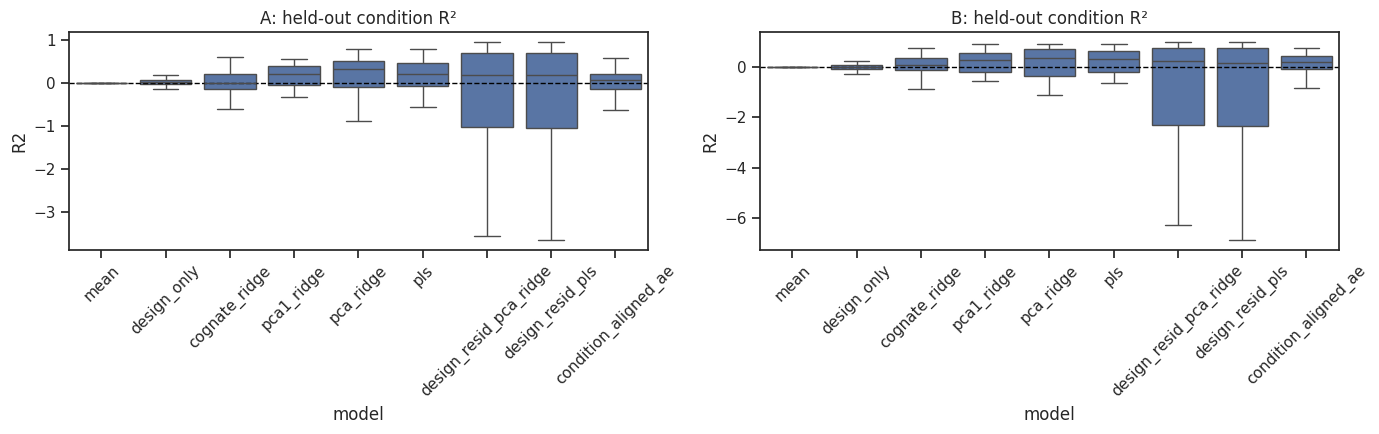

In [7]:
fig, axes = plt.subplots(1, len(DATA), figsize=(7 * len(DATA), 4.5), squeeze=False)
for ax, (lab, tab) in zip(axes[0], R2_TABLES.items()):
    long = tab.reset_index(names="protein").melt(id_vars="protein", var_name="model", value_name="R2")
    sns.boxplot(data=long, x="model", y="R2", ax=ax, showfliers=False)
    ax.axhline(0, ls="--", lw=1, c="black")
    ax.set_title(f"{lab}: held-out condition R²")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "condition_oof_r2.png", dpi=160, bbox_inches="tight")
plt.show()

### Per-condition performance

For each held-out condition we report:

- **RMSE** across proteins; lower is better.
- **Condition-relative R²** across proteins:

\[
R^2_c = 1 - \frac{\sum_p(y_{cp}-\hat y_{cp})^2}
{\sum_p(y_{cp}-\bar y_{train(c),p})^2}
\]

This is the clearest diagnostic for whether one condition, such as `T1|t3`, is unusually easy or difficult.

In [8]:
CONDITION_METRICS = {}
for lab, oof in OOF.items():
    CONDITION_METRICS[lab] = oof_condition_metrics(oof)
    print(f"\n{lab}: condition-relative R2")
    display(
        CONDITION_METRICS[lab]
        .pivot(index="condition", columns="model", values="condition_relative_R2")
        .round(3)
    )
    print(f"{lab}: condition RMSE")
    display(
        CONDITION_METRICS[lab]
        .pivot(index="condition", columns="model", values="rmse")
        .round(3)
    )


A: condition-relative R2


model,cognate_ridge,condition_aligned_ae,design_only,design_resid_pca_ridge,design_resid_pls,mean,pca1_ridge,pca_ridge,pls
condition,,,,,,,,,
T0|t0,0.324,0.177,0.165,-0.207,-0.232,0.0,0.482,0.695,0.660
T0|t1,0.110,-0.166,0.221,-0.530,-0.541,0.0,-0.272,-0.272,-0.185
T0|t2,-0.077,-0.129,-0.013,-0.510,-0.521,0.0,0.095,0.209,0.099
T0|t3,-0.349,-0.165,0.058,-1.171,-1.215,0.0,-0.000,-0.565,-0.007
T1|t0,0.212,0.086,-0.144,0.100,0.083,0.0,0.422,0.422,0.616
T1|t1,-0.687,0.008,-0.013,-0.441,-0.445,0.0,-0.130,-0.955,-1.590
T1|t2,0.311,0.701,0.075,0.566,0.564,0.0,0.391,0.391,0.522
T1|t3,0.268,-0.004,0.002,0.599,0.591,0.0,0.303,0.661,0.431


A: condition RMSE


model,cognate_ridge,condition_aligned_ae,design_only,design_resid_pca_ridge,design_resid_pls,mean,pca1_ridge,pca_ridge,pls
condition,,,,,,,,,
T0|t0,1.629,1.798,1.810,2.177,2.200,1.982,1.426,1.095,1.155
T0|t1,1.164,1.332,1.089,1.526,1.531,1.233,1.391,1.391,1.342
T0|t2,1.072,1.098,1.040,1.270,1.274,1.033,0.983,0.919,0.981
T0|t3,1.277,1.186,1.067,1.620,1.636,1.099,1.099,1.375,1.103
T1|t0,2.016,2.171,2.429,2.155,2.175,2.271,1.727,1.727,1.407
T1|t1,1.537,1.178,1.191,1.420,1.422,1.183,1.257,1.654,1.904
T1|t2,1.616,1.064,1.872,1.281,1.285,1.946,1.518,1.518,1.346
T1|t3,2.181,2.554,2.547,1.614,1.630,2.549,2.128,1.484,1.923



B: condition-relative R2


model,cognate_ridge,condition_aligned_ae,design_only,design_resid_pca_ridge,design_resid_pls,mean,pca1_ridge,pca_ridge,pls
condition,,,,,,,,,
T0|t0,0.257,0.083,0.212,-0.441,-0.629,0.0,0.365,0.365,0.454
T0|t1,0.145,0.149,0.195,0.032,-0.009,0.0,0.265,0.236,0.192
T0|t2,0.110,-0.056,0.039,-0.315,-0.312,0.0,-0.166,-0.166,-0.077
T0|t3,0.088,-0.180,-0.049,-2.030,-2.072,0.0,-0.867,-0.367,-0.679
T1|t0,0.256,0.523,-0.219,-0.615,-0.840,0.0,0.305,0.698,0.391
T1|t1,0.355,0.150,0.035,0.004,-0.015,0.0,0.386,0.041,0.088
T1|t2,0.478,0.854,0.013,0.554,0.555,0.0,0.775,0.855,0.855
T1|t3,0.289,0.070,0.040,0.507,0.503,0.0,0.581,0.589,0.621


B: condition RMSE


model,cognate_ridge,condition_aligned_ae,design_only,design_resid_pca_ridge,design_resid_pls,mean,pca1_ridge,pca_ridge,pls
condition,,,,,,,,,
T0|t0,2.018,2.241,2.078,2.810,2.987,2.341,1.865,1.865,1.730
T0|t1,1.385,1.381,1.344,1.474,1.505,1.498,1.284,1.309,1.346
T0|t2,1.328,1.447,1.381,1.615,1.613,1.408,1.520,1.520,1.461
T0|t3,1.206,1.371,1.293,2.198,2.213,1.262,1.725,1.476,1.636
T1|t0,1.971,1.580,2.524,2.906,3.101,2.286,1.907,1.256,1.784
T1|t1,1.172,1.346,1.434,1.457,1.470,1.460,1.143,1.430,1.394
T1|t2,1.765,0.932,2.427,1.632,1.630,2.443,1.160,0.931,0.931
T1|t3,2.557,2.924,2.972,2.130,2.138,3.033,1.964,1.945,1.868


### Cognate baseline coverage — reviewer issue 1

The previous implementation allowed `cognate_ridge` to fall back to the mean whenever the cognate transcript was not among the top-variable RNA features. That made a near-zero cognate R² difficult to interpret.

In this version, cognate transcripts bypass the generic top-N variance selection. The table below reports how often a mapped transcript was actually present and variable across outer-training conditions.

In [9]:
COGNATE_COVERAGE = {}
for lab, oof in OOF.items():
    cov = cognate_coverage_table(oof)
    COGNATE_COVERAGE[lab] = cov
    summary = pd.Series({
        "proteins_scored": len(cov),
        "present_in_all_folds": int((cov["fraction_folds_cognate_present"] == 1).sum()),
        "variable_in_all_folds": int((cov["fraction_folds_cognate_variable"] == 1).sum()),
        "mean_fraction_folds_present": cov["fraction_folds_cognate_present"].mean(),
        "mean_fraction_folds_variable": cov["fraction_folds_cognate_variable"].mean(),
    })
    print(f"\n{lab}: cognate coverage")
    display(summary.to_frame("value"))
    display(cov.sort_values(["fraction_folds_cognate_present", "fraction_folds_cognate_variable"]).head(15))
    cov.to_csv(OUT_DIR / f"{lab}_cognate_coverage.csv")


A: cognate coverage


,value
proteins_scored,210.000000
present_in_all_folds,210.000000
variable_in_all_folds,198.000000
mean_fraction_folds_present,1.000000
mean_fraction_folds_variable,0.947024


,cognate_present_folds,cognate_variable_folds,fraction_folds_cognate_present,fraction_folds_cognate_variable
protein,,,,
TraesNOR2A03G00636370,8,0,1.0,0.000
TraesNORUn03G04710470,8,0,1.0,0.000
TraesNOR5D03G03209140,8,0,1.0,0.000
TraesNORUn03G04619660,8,0,1.0,0.000
TraesNOR5D03G03206860,8,0,1.0,0.000
TraesNOR4B03G02359230,8,0,1.0,0.000
TraesNOR5B03G03017820,8,0,1.0,0.000
TraesNOR3D03G01958940,8,0,1.0,0.000
TraesNORUn03G04701450,8,0,1.0,0.000



B: cognate coverage


,value
proteins_scored,226.000000
present_in_all_folds,226.000000
variable_in_all_folds,218.000000
mean_fraction_folds_present,1.000000
mean_fraction_folds_variable,0.964602


,cognate_present_folds,cognate_variable_folds,fraction_folds_cognate_present,fraction_folds_cognate_variable
protein,,,,
TraesCAD_scaffold_067098_01G000300,8,0,1.0,0.0
TraesCAD_scaffold_146234_01G000100,8,0,1.0,0.0
TraesCAD_scaffold_016160_01G000300,8,0,1.0,0.0
TraesCAD_scaffold_013880_01G000300,8,0,1.0,0.0
TraesCAD_scaffold_069613_01G000100,8,0,1.0,0.0
TraesCAD_scaffold_143552_01G000200,8,0,1.0,0.0
TraesCAD_scaffold_008279_01G000200,8,0,1.0,0.0
TraesCAD_scaffold_019645_01G000300,8,0,1.0,0.0
TraesCAD_scaffold_037061_01G000200,8,8,1.0,1.0


### Nested component selection — reviewer issue 2

The previous PCA model used three components despite having only seven training conditions in each outer fold. The component counts below are now chosen by an **inner leave-one-condition-out CV using only the seven outer-training conditions**. This prevents the held-out condition from influencing model dimensionality.

In [10]:
for lab, oof in OOF.items():
    print(f"\n{lab}: selected latent dimensions by outer fold")
    display(oof["component_selection"])


A: selected latent dimensions by outer fold


,fold,held,pca_components,pls_components,design_resid_pca_components,design_resid_pls_components
0,0,T0|t0,3,1,2,2
1,1,T1|t0,1,1,2,2
2,2,T0|t1,1,1,2,2
3,3,T1|t1,3,2,3,2
4,4,T0|t2,3,1,2,2
5,5,T1|t2,1,1,2,2
6,6,T0|t3,3,1,2,2
7,7,T1|t3,3,1,3,2



B: selected latent dimensions by outer fold


,fold,held,pca_components,pls_components,design_resid_pca_components,design_resid_pls_components
0,0,T0|t0,1,1,3,2
1,1,T1|t0,3,1,3,2
2,2,T0|t1,3,2,2,2
3,3,T1|t1,2,2,3,2
4,4,T0|t2,1,1,3,2
5,5,T1|t2,2,2,2,2
6,6,T0|t3,3,1,3,2
7,7,T1|t3,2,2,3,2


### Low-rank and experimental-design controls

Interpret these comparisons together:

- `pca1_ridge ≈ pca_ridge`: much of the prediction may be carried by a single global RNA response axis.
- `pca_ridge > design_only` but `design_resid_pca_ridge ≈ design_only` or worse: much of PCA's advantage may be shared treatment/time structure.
- `design_resid_pca_ridge` or `design_resid_pls` still clearly outperform `design_only`: RNA contains predictive structure beyond treatment/timepoint main effects.

These controls do not establish causality, but they make the claim more precise.

In [11]:
CONTROL_COMPARISON = SUMMARY[SUMMARY["model"].isin([
    "design_only", "pca1_ridge", "pca_ridge", "pls",
    "design_resid_pca_ridge", "design_resid_pls",
])].copy()
display(CONTROL_COMPARISON.sort_values(["variety", "median_R2"], ascending=[True, False]))

,variety,model,median_R2,mean_R2,fraction_R2_positive,n_proteins
4,A,pca_ridge,0.330095,0.189164,0.695238,210
3,A,pca1_ridge,0.209167,0.177893,0.719048,210
5,A,pls,0.208064,0.186847,0.676190,210
6,A,design_resid_pca_ridge,0.201560,-0.494347,0.576190,210
7,A,design_resid_pls,0.199049,-0.528671,0.576190,210
1,A,design_only,0.024723,0.014237,0.623810,210
13,B,pca_ridge,0.362485,0.163664,0.610619,226
14,B,pls,0.326178,0.222349,0.623894,226
12,B,pca1_ridge,0.265673,0.208519,0.632743,226
15,B,design_resid_pca_ridge,0.217418,-1.249284,0.539823,226


### Condition leverage / sensitivity

This diagnostic recomputes the headline **median protein R² after removing one held-out condition from the score**. The models are not retrained; the purpose is to determine whether a single condition disproportionately drives the aggregate R².

In [12]:
SENSITIVITY = {}
for lab, oof in OOF.items():
    sens = condition_score_sensitivity(oof)
    SENSITIVITY[lab] = sens
    focus = sens[sens["model"].isin([
        "pca1_ridge", "pca_ridge", "pls",
        "design_resid_pca_ridge", "design_resid_pls",
        "condition_aligned_ae",
    ])].copy()
    focus["abs_delta"] = focus["delta_median_R2"].abs()
    print(f"\n{lab}: largest changes in median R2 after omitting one condition")
    display(focus.sort_values("abs_delta", ascending=False).head(20).drop(columns="abs_delta"))
    sens.to_csv(OUT_DIR / f"{lab}_condition_score_sensitivity.csv", index=False)


A: largest changes in median R2 after omitting one condition


,omitted_condition,model,median_R2_without_condition,full_median_R2,delta_median_R2
67,T1|t3,pca_ridge,0.189174,0.330095,-0.140921
69,T1|t3,design_resid_pca_ridge,0.068702,0.201560,-0.132858
32,T1|t1,pls,0.327901,0.208064,0.119837
70,T1|t3,design_resid_pls,0.080298,0.199049,-0.118751
51,T1|t2,design_resid_pca_ridge,0.090352,0.201560,-0.111208
52,T1|t2,design_resid_pls,0.093793,0.199049,-0.105256
4,T0|t0,pca_ridge,0.242269,0.330095,-0.087826
24,T0|t1,design_resid_pca_ridge,0.281716,0.201560,0.080155
53,T1|t2,condition_aligned_ae,0.002541,0.081332,-0.078791
31,T1|t1,pca_ridge,0.398974,0.330095,0.068879



B: largest changes in median R2 after omitting one condition


,omitted_condition,model,median_R2_without_condition,full_median_R2,delta_median_R2
69,T1|t3,design_resid_pca_ridge,0.016933,0.217418,-0.200486
70,T1|t3,design_resid_pls,0.000229,0.142140,-0.141911
51,T1|t2,design_resid_pca_ridge,0.078159,0.217418,-0.139259
52,T1|t2,design_resid_pls,0.003936,0.142140,-0.138204
57,T0|t3,pca1_ridge,0.370167,0.265673,0.104494
59,T0|t3,pls,0.425540,0.326178,0.099362
66,T1|t3,pca1_ridge,0.166597,0.265673,-0.099076
16,T1|t0,design_resid_pls,0.237902,0.142140,0.095762
48,T1|t2,pca1_ridge,0.174395,0.265673,-0.091278
53,T1|t2,condition_aligned_ae,0.123929,0.214296,-0.090367


## 6 — Fit the condition-aligned autoencoder on all samples

This fit is for **latent-space interpretation**, not for reporting predictive performance. Predictive claims must come from the out-of-fold results above.

The expected geometry is that RNA and protein samples from the same experimental condition occupy nearby regions in the shared latent space, even though individual replicates are not paired.

In [13]:
FULL = {}
for lab, d in DATA.items():
    print(f"fitting full-data latent model for {lab}...")
    pre, ae, R, P = fit_full_condition_ae(d, pre_kwargs=PRE_KWARGS, ae_kwargs=AE_KWARGS)
    coords = latent_coordinates(d, ae, R, P)
    distances = latent_centroid_distances(d, ae, R, P)
    FULL[lab] = dict(pre=pre, ae=ae, R=R, P=P, coords=coords, distances=distances)
    display(distances.sort_values("latent_centroid_distance"))

fitting full-data latent model for A...


,condition,latent_centroid_distance
2,T0|t1,0.080717
1,T1|t0,0.081158
5,T1|t2,0.096459
0,T0|t0,0.123601
3,T1|t1,0.126570
4,T0|t2,0.189144
7,T1|t3,0.203814
6,T0|t3,0.653184


fitting full-data latent model for B...


,condition,latent_centroid_distance
0,T0|t0,0.101107
1,T1|t0,0.140116
5,T1|t2,0.150737
3,T1|t1,0.157874
4,T0|t2,0.167281
2,T0|t1,0.196902
7,T1|t3,0.230295
6,T0|t3,0.326510


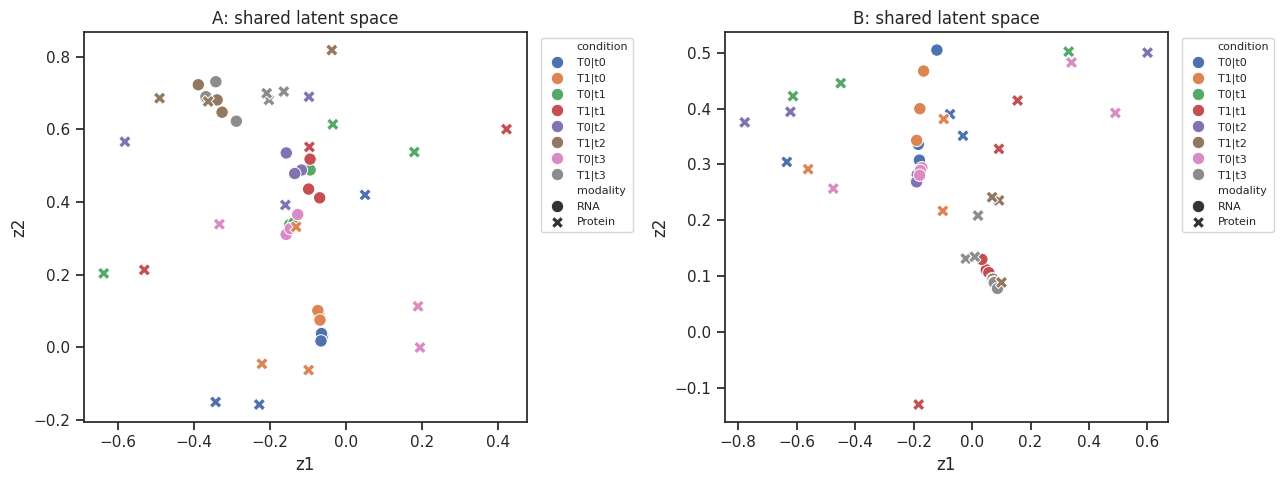

In [14]:
fig, axes = plt.subplots(1, len(DATA), figsize=(6.5 * len(DATA), 5), squeeze=False)
for ax, (lab, obj) in zip(axes[0], FULL.items()):
    z = obj["coords"].reset_index(names="sample")
    if "z2" not in z:
        continue
    sns.scatterplot(
        data=z, x="z1", y="z2", hue="condition", style="modality",
        s=80, ax=ax
    )
    ax.set_title(f"{lab}: shared latent space")
    ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "shared_latent_space.png", dpi=160, bbox_inches="tight")
plt.show()

## 7 — Condition-level RNA–protein residuals

For a held-out condition \(c\) and protein \(p\):

\[
D_{cp} = Protein^{observed}_{cp} - Protein^{predicted\ from\ RNA}_{cp}
\]

These are **condition-level residuals**. They are not individual-sample RNA/protein discordance scores because the biological samples are independent.

Large residuals can identify conditions/proteins for follow-up, but with only ~8 conditions they should initially be treated as **descriptive**, not as strong evidence of post-transcriptional regulation.

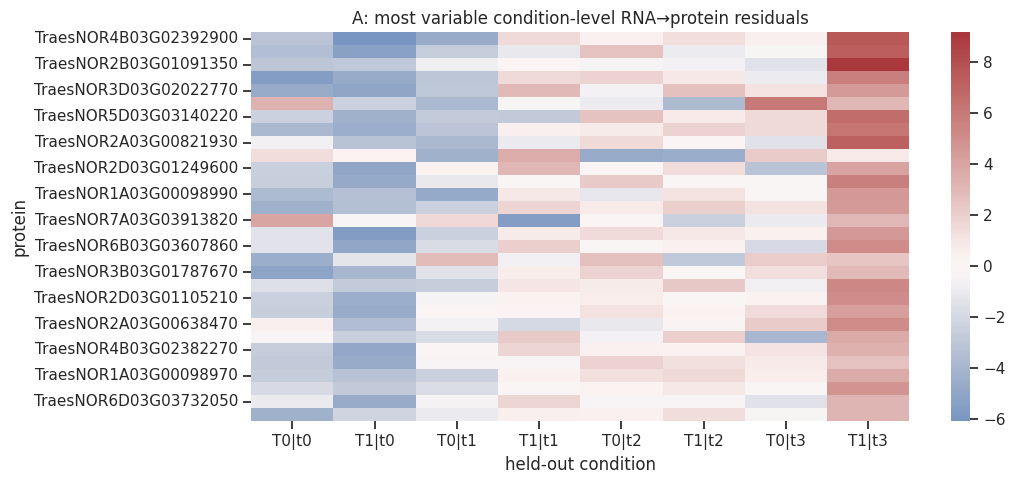

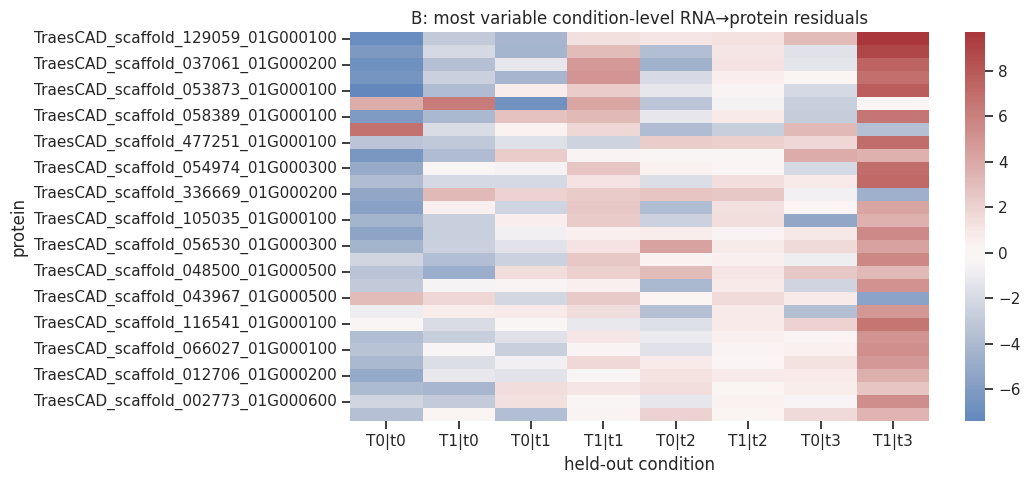

In [15]:
RESIDUALS = {}
for lab, oof in OOF.items():
    D = condition_residuals(oof, model="condition_aligned_ae")
    RESIDUALS[lab] = D
    D.to_csv(OUT_DIR / f"{lab}_condition_residuals.csv")

    top = D.var(axis=0).sort_values(ascending=False).head(min(30, D.shape[1])).index
    plt.figure(figsize=(11, 5))
    sns.heatmap(D.loc[:, top].T, center=0, cmap="vlag")
    plt.title(f"{lab}: most variable condition-level RNA→protein residuals")
    plt.xlabel("held-out condition")
    plt.ylabel("protein")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "figures" / f"{lab}_condition_residual_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()

## 8 — Permutation/null tests — reviewer issue 3

The null shuffles **complete protein condition labels**, preserving all proteomics replicates within a condition. It breaks RNA–protein condition correspondence while preserving the marginal experimental structure.

The permutation test uses the **same protein targets as the observed run**, avoiding a different target set under the null.

Important interpretation:

> A significant permutation test means RNA and protein condition states correspond more strongly than random condition matching. It does **not** prove that RNA causally determines protein abundance; a genuine shared biological response/severity axis may still contribute.

Use the one-PC and design-residualised controls above to refine that interpretation. With `N_PERM=200`, the smallest attainable empirical p-value is about 0.005.

In [16]:
PERM, PERM_PVALUES = {}, {}

if RUN_PERMUTATIONS:
    for lab, d in DATA.items():
        print(f"\nPermutation null: {lab}")
        null = permutation_null(
            d,
            n_perm=N_PERM,
            seed=SEED,
            models=PERM_MODELS,
            reference_proteins=OOF[lab]["proteins"],
            pre_kwargs=PRE_KWARGS,
            ae_kwargs=AE_KWARGS,
            pca_components=PCA_COMPONENTS,
            pls_components=PLS_COMPONENTS,
            tune_components=TUNE_COMPONENTS,
        )
        PERM[lab] = null
        ptab = permutation_pvalue_table(OOF[lab], null)
        PERM_PVALUES[lab] = ptab
        display(ptab)
        null.to_csv(OUT_DIR / f"{lab}_permutation_null.csv")
        ptab.to_csv(OUT_DIR / f"{lab}_permutation_pvalues.csv", index=False)
else:
    print("Linear permutation analysis skipped. Set RUN_PERMUTATIONS=True for the final validation run.")

# The AE null is intentionally separate because retraining the network for every
# permutation is much more expensive.
AE_PERM, AE_PERM_PVALUES = {}, {}
if RUN_AE_PERMUTATIONS:
    for lab, d in DATA.items():
        print(f"\nAE permutation null: {lab}")
        null = permutation_null(
            d,
            n_perm=N_PERM_AE,
            seed=SEED + 1000,
            models=["condition_aligned_ae"],
            reference_proteins=OOF[lab]["proteins"],
            pre_kwargs=PRE_KWARGS,
            ae_kwargs=AE_KWARGS,
            pca_components=PCA_COMPONENTS,
            pls_components=PLS_COMPONENTS,
            tune_components=TUNE_COMPONENTS,
        )
        AE_PERM[lab] = null
        ptab = permutation_pvalue_table(OOF[lab], null)
        AE_PERM_PVALUES[lab] = ptab
        display(ptab)


Permutation null: A
  permutation 10/200
  permutation 20/200
  permutation 30/200
  permutation 40/200
  permutation 50/200
  permutation 60/200
  permutation 70/200
  permutation 80/200
  permutation 90/200
  permutation 100/200
  permutation 110/200
  permutation 120/200
  permutation 130/200
  permutation 140/200
  permutation 150/200
  permutation 160/200
  permutation 170/200
  permutation 180/200
  permutation 190/200
  permutation 200/200


,model,observed_median_R2,null_mean,null_median,null_q95,empirical_p,n_perm
3,design_resid_pca_ridge,0.201560,-2.035612,-1.384273,0.076498,0.009950,200
4,design_resid_pls,0.199049,-2.122565,-1.472858,0.051221,0.009950,200
1,pca_ridge,0.330095,-0.136262,-0.114634,0.228971,0.014925,200
0,pca1_ridge,0.209167,-0.040396,-0.057891,0.161717,0.039801,200
2,pls,0.208064,-0.216643,-0.202900,0.277637,0.109453,200



Permutation null: B
  permutation 10/200
  permutation 20/200
  permutation 30/200
  permutation 40/200
  permutation 50/200
  permutation 60/200
  permutation 70/200
  permutation 80/200
  permutation 90/200
  permutation 100/200
  permutation 110/200
  permutation 120/200
  permutation 130/200
  permutation 140/200
  permutation 150/200
  permutation 160/200
  permutation 170/200
  permutation 180/200
  permutation 190/200
  permutation 200/200


,model,observed_median_R2,null_mean,null_median,null_q95,empirical_p,n_perm
3,design_resid_pca_ridge,0.217418,-3.403527,-2.217013,-0.257610,0.004975,200
4,design_resid_pls,0.142140,-3.844923,-2.305982,-0.327683,0.009950,200
1,pca_ridge,0.362485,-0.265087,-0.275579,0.166580,0.014925,200
0,pca1_ridge,0.265673,-0.154745,-0.187865,0.080248,0.019900,200
2,pls,0.326178,-0.249654,-0.274296,0.162415,0.019900,200


## 9 — Optional cross-variety comparison through orthologs

The varieties are still modelled independently. If you provide an ortholog table, compare prediction performance only after mapping proteins between varieties.

In [17]:
from rnaprot.multivariety import load_ortholog_map

if ORTHOLOG_CSV is not None and len(R2_TABLES) >= 2:
    labs = list(R2_TABLES)[:2]
    a, b = labs

    def _rna_condition_means(d):
        # Same definition as rnaprot.multivariety.rna_condition_means(), but
        # UnpairedOmicsData exposes rna_meta (not meta), so this is inlined
        # rather than reusing that helper directly.
        cond = d.rna_meta["treatment"].astype(str) + "|" + d.rna_meta["timepoint"].astype(str)
        return d.rna.groupby(cond.to_numpy()).mean()

    # RBH is frequently many-to-many; load_ortholog_map() collapses each id_a
    # to one id_b, breaking multi-way ties with condition-mean RNA expression
    # correlation instead of silently pseudoreplicating tied candidates.
    rna_cm_a = _rna_condition_means(DATA[a])
    rna_cm_b = _rna_condition_means(DATA[b])
    ortho = load_ortholog_map(ORTHOLOG_CSV, rna_a=rna_cm_a, rna_b=rna_cm_b)
    ortho.to_csv(OUT_DIR / "ortholog_map.csv", index=False)

    n_o = len(ortho)
    n_tied = int((ortho["n_candidates"] > 1).sum())
    resolved = ortho.loc[ortho.resolution == "expression_resolved_tie", "best_corr"]
    print(f"ortholog map: {n_o:,} pairs "
          f"({(ortho.resolution == 'unambiguous').sum():,} unambiguous, "
          f"{len(resolved):,} tie-resolved by expression"
          + (f" [median best_corr={resolved.median():.2f}]" if len(resolved) else "")
          + f", {(ortho.resolution == 'unresolved_tie').sum():,} unresolved)")
    tie_frac = n_tied / n_o if n_o else 0.0
    print(f"  {tie_frac:.1%} of matched genes hit a multi-way RBH tie")

    ra = R2_TABLES[a]["condition_aligned_ae"].rename("R2_a").rename_axis("id_a").reset_index()
    rb = R2_TABLES[b]["condition_aligned_ae"].rename("R2_b").rename_axis("id_b").reset_index()
    comp = ortho.merge(ra, on="id_a", how="inner").merge(rb, on="id_b", how="inner")
    print(f"orthologs with R\u00b2 in both varieties: {len(comp)}")
    display(comp.head())
    if len(comp) >= 3:
        rho = comp[["R2_a", "R2_b"]].corr(method="spearman").iloc[0, 1]
        print("Spearman R\u00b2 concordance (full ortholog map):", rho)

    # sensitivity check: does restricting to unambiguous RBH hits change the
    # headline concordance? if not, the expression tie-break wasn't doing
    # much work; if it does, that belongs explicitly in the methods.
    unamb = ortho[ortho.resolution == "unambiguous"]
    comp_unamb = unamb.merge(ra, on="id_a", how="inner").merge(rb, on="id_b", how="inner")
    if len(comp_unamb) >= 3:
        rho_u = comp_unamb[["R2_a", "R2_b"]].corr(method="spearman").iloc[0, 1]
        print(f"  sensitivity check, unambiguous_rbh only: n={len(comp_unamb):,} | "
              f"Spearman rho={rho_u:.3f}")

    comp.to_csv(OUT_DIR / "cross_variety_r2_concordance.csv", index=False)
else:
    print("No ortholog table configured; per-variety analysis is complete.")


[load_ortholog_map] 420 multi-way ties kept their first candidate (no rna_a/rna_b given, or no usable expression profile) -- treat these rows as lower confidence, see the 'resolution' column
ortholog map: 81,761 pairs (78,693 unambiguous, 2,648 tie-resolved by expression [median best_corr=0.85], 420 unresolved)
  3.8% of matched genes hit a multi-way RBH tie
orthologs with R² in both varieties: 45


,id_a,id_b,n_candidates,resolution,best_corr,R2_a,R2_b
0,TraesNOR1A03G00091890,TraesCAD_scaffold_068638_01G000100,1,unambiguous,NaN,-0.011436,0.455018
1,TraesNOR1A03G00098970,TraesCAD_scaffold_110001_01G000200,1,unambiguous,NaN,0.240666,0.515134
2,TraesNOR1A03G00119210,TraesCAD_scaffold_038598_01G000200,1,unambiguous,NaN,0.184315,0.492378
3,TraesNOR1A03G00122170,TraesCAD_scaffold_011627_01G000100,1,unambiguous,NaN,-0.011278,0.264198
4,TraesNOR1B03G00403960,TraesCAD_scaffold_044525_01G000400,1,unambiguous,NaN,-0.523913,0.412237


Spearman R² concordance (full ortholog map): 0.27509881422924903
  sensitivity check, unambiguous_rbh only: n=44 | Spearman rho=0.330


## 10 — Interpretation checklist

Before making biological claims:

1. **Cognate baseline:** confirm `fraction_folds_cognate_present` is high; a missing mapping is now explicit rather than silently caused by top-N RNA selection.
2. **Dimensionality:** report the inner-CV-selected PCA/PLS component counts rather than assuming three components are justified.
3. **Global-axis check:** compare `pca1_ridge` with `pca_ridge`. Similar performance means a single broad response axis explains much of the prediction.
4. **Design-confounding check:** compare `design_resid_pca_ridge`/`design_resid_pls` with `design_only`. Positive incremental performance is stronger evidence that RNA contains information beyond treatment/timepoint main effects.
5. **Condition leverage:** inspect per-condition R²/RMSE and the score-sensitivity table. A single condition should not account for the whole headline result.
6. **Permutation null:** compare observed median R² against condition-label permutations on the same protein targets.
7. **Causal language:** even a significant null supports *cross-modal condition correspondence*, not causal RNA→protein regulation.
8. **Autoencoder:** interpret AE residuals strongly only if the AE has positive held-out performance and a defensible null result.
9. **Unpaired samples:** never infer replicate-specific RNA→protein or lag relationships when the assays used independent biological material.

### Why the AE does not receive treatment/timepoint as input

Treatment/timepoint labels are used to define alignment groups and CV folds, but they are not concatenated to the AE input. The explicit `design_only` and design-residualised controls isolate how much prediction comes from known experimental structure.